# End-to-End Sales Forecasting & Demand Intelligence System

### Final Internship Project

**Intern:** Naman Arora

---

## Project Overview

This project develops an end-to-end Sales Forecasting and Demand Intelligence System that analyzes historical retail sales data to forecast future demand, detect anomalous sales patterns, segment products based on demand behavior, and provide an interactive dashboard for business decision-making.

The project combines statistical forecasting, machine learning, clustering, and data visualization techniques to support data-driven inventory planning.

## Objectives

- Analyze historical sales trends and seasonality.
- Forecast future sales using multiple forecasting models.
- Detect unusual sales patterns.
- Segment products based on demand characteristics.
- Develop an interactive Streamlit dashboard.
- Generate actionable business insights.

# Task 1 — Data Loading, Merging & Deep Exploration

## 1. Load the Superstore Sales CSV using Pandas


In [30]:
import pandas as pd
df = pd.read_csv("data/train.csv")
print(df.head(5))


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

## 2. Parse the Order Date and Ship Date columns as proper datetime objects

In [31]:
# Convert date columns into datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


## 3. Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season


In [32]:
# Extract Year
df["Year"] = df["Order Date"].dt.year

# Extract Month
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

# Extract Week Number
df["Week Number"] = df["Order Date"].dt.isocalendar().week.astype(int)

# Extract Day of Week
df["Day of Week"] = df["Order Date"].dt.day_name()

# Extract Quarter
df["Quarter"] = df["Order Date"].dt.quarter

# Function to assign seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

# Season column
df["Season"] = df["Month"].apply(get_season)

df[[
    "Order Date",
    "Year",
    "Month",
    "Month Name",
    "Week Number",
    "Day of Week",
    "Quarter",
    "Season"
]].head()

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,June,24,Monday,2,Summer
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn


## 4. Check for missing values, duplicates, and data type issues

In [33]:
# Missing Values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

# Duplicate Records
print(f"Duplicate Records: {df.duplicated().sum()}")

# Data Types
df.dtypes

Duplicate Records: 0


Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Month Name                  str
Week Number               int64
Day of Week                 str
Quarter                   int32
Season                      str
dtype: object

## 5. Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)

In [34]:
# Sale by date
daily_sales = (
    df.groupby("Order Date", as_index=False)["Sales"]
      .sum()
)

# Sale by week
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

# Sale by month
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

print("Daily Sales:")
print(daily_sales.head())

print("Weekly Sales:")
print(weekly_sales.head())

print("Monthly Sales:")
print(monthly_sales.head())

Daily Sales:
  Order Date     Sales
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158
Weekly Sales:
  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914
Monthly Sales:
  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


#### Daily, weekly, and monthly sales aggregations are created because different forecasting models and business analyses require different levels of time granularity. Daily data captures fine-grained fluctuations, weekly data reduces short-term noise, and monthly data highlights long-term trends and seasonality.

## 6. Answer these questions in your notebook with data to back each one:
1. Which product category generates the highest total revenue?
2. Which region has the most consistent sales growth over 4 years?
3. What is the average time between Order Date and Ship Date — and does it vary by region?
4. Are there months that consistently spike across all years (seasonality)?

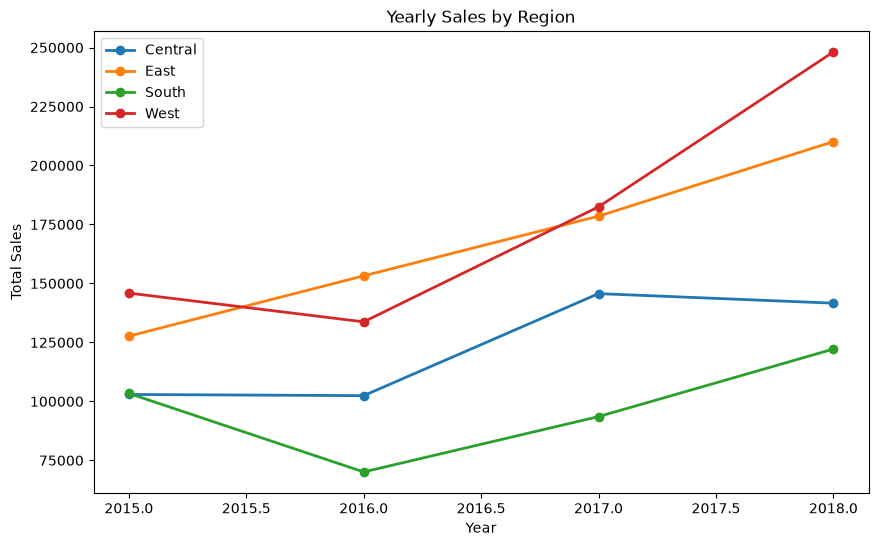

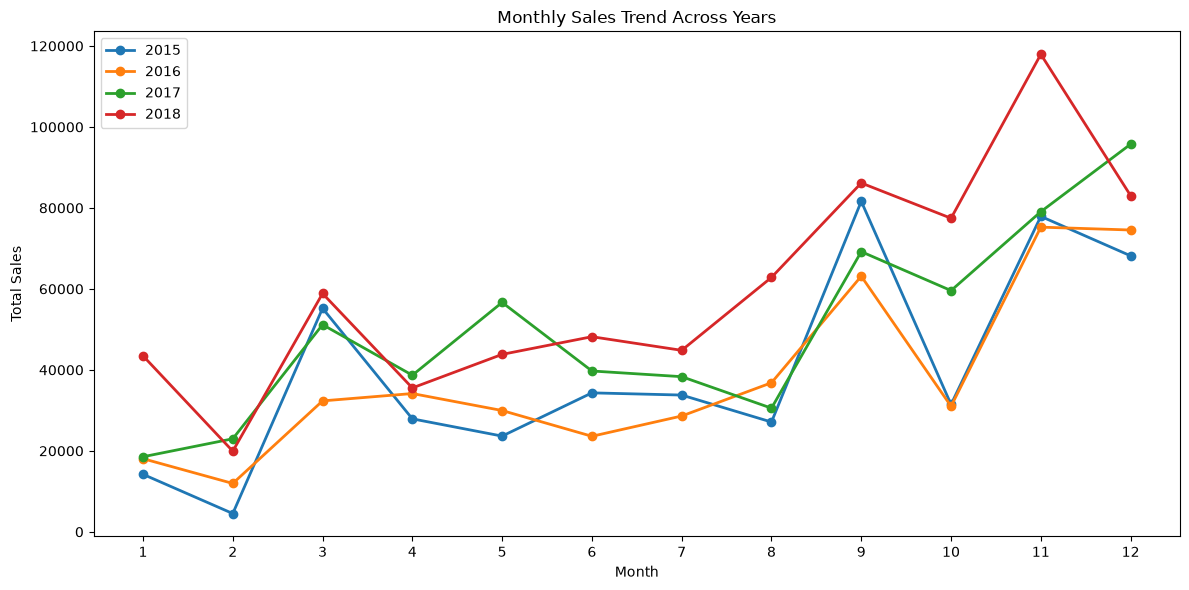

In [ ]:
# 1. Product category generates the highest total revenue
highest_sales_category = (
    df.groupby("Category", as_index=False)["Sales"]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

highest_sales_category.head(1)

# 2.Region with the most consistent sales growth over 4 years
import matplotlib.pyplot as plt

region_sales = (
    df.groupby(["Year", "Region"], as_index=False)["Sales"]
      .sum()
)

plt.figure(figsize=(10,6))

for region in region_sales["Region"].unique():

    temp = region_sales[region_sales["Region"] == region]

    plt.plot(
        temp["Year"],
        temp["Sales"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=region
    )

plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend()


plt.show()

# Therefore, the region with the most consistent sales growth 
# over 4 years can be determined by analyzing the plotted lines 
# for each region. The region with a steady upward trend 
# without significant fluctuations would be considered the 
# most consistent.

# 3.The average time between Order Date and Ship Date — 
# and does it vary by region

# Calculate Shipping Days
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

# Average Shipping Time by Region
shipping_time = (
    df.groupby("Region", as_index=False)["Shipping Days"]
      .mean()
      .sort_values(by="Shipping Days", ascending=False)
)

shipping_time

#4. Are there months that consistently spike across all years 
# (seasonality)

# Monthly Sales by Year
monthly_pattern = (
    df.groupby(["Year", "Month"], as_index=False)["Sales"]
      .sum()
)

monthly_pattern.head()

plt.figure(figsize=(12,6))

for year in sorted(monthly_pattern["Year"].unique()):

    temp = monthly_pattern[
        monthly_pattern["Year"] == year
    ]

    plt.plot(
        temp["Month"],
        temp["Sales"],
        marker="o",
        linewidth=2,
        label=year
    )

plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend Across Years")
plt.legend()
plt.tight_layout()
plt.show()





#### Therefore, the region with the most consistent sales growth over 4 years can be determined by analyzing the plotted lines for each region. The region with a steady upward trend without significant fluctuations would be considered the most consistent.

#### The monthly sales trends indicate clear seasonality. March, September, and November consistently experience higher sales across the four-year period, suggesting recurring periods of increased customer demand. These seasonal peaks can help businesses optimize inventory planning, staffing, and promotional campaigns.
